In [1]:
import numpy as np
import pandas as pd
import pickle

X = np.load('../data/X.npy')
y = np.load('../data/y.npy')

feature_names = pickle.load(open('../models/features.pkl', 'rb'))
model = pickle.load(open('../models/model.pkl', 'rb'))
scaler = pickle.load(open('../models/scaler.pkl', 'rb'))

In [3]:
#Feature Selection (SHAP-based)
# Convert to DataFrame for easier handling
X_df = pd.DataFrame(X, columns=feature_names)

# Based on your SHAP results (top features)
selected_features = [
    'specific gravity', 'hemoglobin', 'hypertension', 'packed cell volume', 'appetite',
    'diabetes mellitus', 'albumin', 'blood glucose random', 'red blood cell count', 'blood urea'
]

# Subset dataset
X_selected = X_df[selected_features].values

print("Selected features:", selected_features)
print("New shape:", X_selected.shape)

Selected features: ['specific gravity', 'hemoglobin', 'hypertension', 'packed cell volume', 'appetite', 'diabetes mellitus', 'albumin', 'blood glucose random', 'red blood cell count', 'blood urea']
New shape: (385, 10)


In [5]:
# Retrain Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale
scaler_new = StandardScaler()
X_train = scaler_new.fit_transform(X_train)
X_test = scaler_new.transform(X_test)

# Train
model_new = LogisticRegression(max_iter=1000)
model_new.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
from sklearn.metrics import recall_score

y_pred = model_new.predict(X_test)
print("Recall (new model):", recall_score(y_test, y_pred))

Recall (new model): 0.9787234042553191


In [7]:
# Calibration
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    model_new,
    method='sigmoid',
    cv=5
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegre...max_iter=1000)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprec

In [8]:
# Compare Probabilities
y_prob_uncal = model_new.predict_proba(X_test)[:, 1]
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

print("Uncalibrated sample:", y_prob_uncal[:5])
print("Calibrated sample:", y_prob_cal[:5])

Uncalibrated sample: [9.27221596e-01 6.11555659e-04 9.99962084e-01 6.22876670e-04
 2.13576320e-02]
Calibrated sample: [0.77595517 0.0155912  0.99486411 0.01527571 0.10265798]


In [9]:
# Threshold Optimization
import numpy as np
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob_cal >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    
    results.append((t, recall, precision))
    print(f"Threshold {t:.2f} → Recall: {recall:.4f}, Precision: {precision:.4f}")

Threshold 0.10 → Recall: 1.0000, Precision: 0.7705
Threshold 0.15 → Recall: 1.0000, Precision: 0.8393
Threshold 0.20 → Recall: 1.0000, Precision: 0.9038
Threshold 0.25 → Recall: 1.0000, Precision: 0.9400
Threshold 0.30 → Recall: 1.0000, Precision: 0.9592
Threshold 0.35 → Recall: 1.0000, Precision: 0.9792
Threshold 0.40 → Recall: 0.9787, Precision: 1.0000
Threshold 0.45 → Recall: 0.9787, Precision: 1.0000
Threshold 0.50 → Recall: 0.9787, Precision: 1.0000
Threshold 0.55 → Recall: 0.9787, Precision: 1.0000
Threshold 0.60 → Recall: 0.9787, Precision: 1.0000
Threshold 0.65 → Recall: 0.9787, Precision: 1.0000
Threshold 0.70 → Recall: 0.9787, Precision: 1.0000
Threshold 0.75 → Recall: 0.9362, Precision: 1.0000
Threshold 0.80 → Recall: 0.8936, Precision: 1.0000
Threshold 0.85 → Recall: 0.8723, Precision: 1.0000


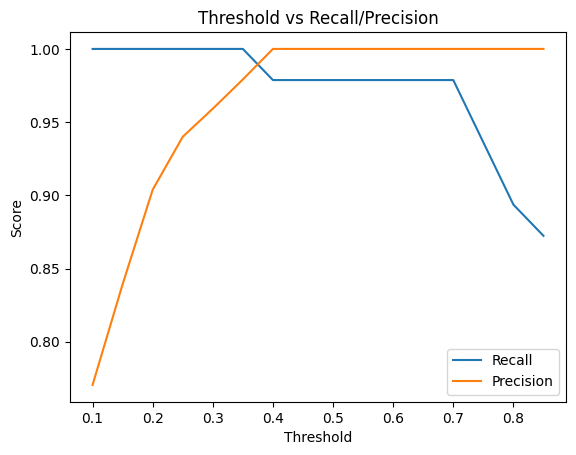

In [10]:
# Plot
import matplotlib.pyplot as plt

t_vals = [r[0] for r in results]
recalls = [r[1] for r in results]
precisions = [r[2] for r in results]

plt.plot(t_vals, recalls, label="Recall")
plt.plot(t_vals, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Recall/Precision")
plt.legend()
plt.show()

In [11]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_new,
    X_selected,
    y,
    cv=5,
    scoring='recall'
)

print("Cross-validated Recall:", scores)
print("Mean Recall:", scores.mean())
print("Std Dev:", scores.std())

Cross-validated Recall: [1.         0.9787234  0.95744681 0.95744681 0.93617021]
Mean Recall: 0.9659574468085108
Std Dev: 0.021697955376990555
